In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
# Helper functions
def make_pie_counts(df, column="primary_disease", min_frac=0.02):
    """Count tissues, grouping categories below min_frac into Other."""
    counts = df[column].dropna().value_counts()
    if counts.empty:
        return counts

    frac = counts / counts.sum()
    major = counts.loc[frac >= min_frac].copy()
    minor = counts.loc[frac < min_frac]

    if len(minor) > 0:
        major.loc["Other"] = minor.sum()

    return major.sort_values(ascending=False)


def order_like_reference(counts, reference_order):
    """Order a tissue count series to match the first pie chart."""
    counts = counts.copy()

    ordered_labels = [label for label in reference_order if label in counts.index]
    extra_labels = [label for label in counts.index if label not in reference_order and label != "Other"]

    # Keep any unexpected new tissues just before Other.
    final_order = ordered_labels + extra_labels
    if "Other" in counts.index and "Other" not in final_order:
        final_order.append("Other")

    return counts.loc[final_order]


def make_color_map(labels, cmap_name="Greens"):
    """Create a consistent color map from the first pie chart order."""
    cmap = plt.get_cmap(cmap_name)
    n = len(labels)
    colors = [cmap(0.3 + 0.6 * (i / (n - 1 if n > 1 else 1))) for i in range(n)]
    return dict(zip(labels, colors))


def plot_tissue_pie(counts, title, color_map=None, figsize=(6, 6), autopct="%1.1f%%"):
    """Plot a primary disease pie chart with optional consistent colors."""
    if counts.empty:
        raise ValueError("No rows available to plot.")

    colors = None
    if color_map is not None:
        colors = [color_map.get(label, "lightgray") for label in counts.index]

    fig, ax = plt.subplots(figsize=figsize)
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct=autopct,
        startangle=90,
        colors=colors,
    )
    ax.set_title(title)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

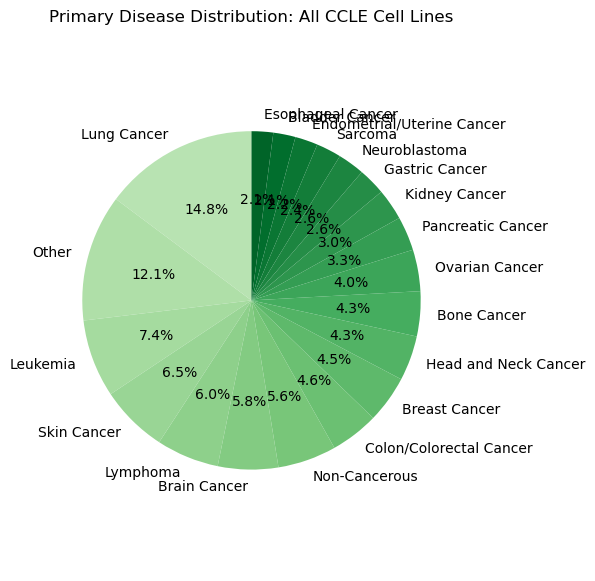

In [3]:
# All STARMAP
# Read sample metadata
info = pd.read_csv("sample_info.csv")

# Use one row per cell line
info_unique = info.drop_duplicates(subset="DepMap_ID")

# First pie chart: this defines the reference order and colors
all_counts = make_pie_counts(info_unique)
reference_order = all_counts.index.tolist()
color_map = make_color_map(reference_order)

plot_tissue_pie(
    all_counts,
    title="Primary Disease Distribution: All CCLE Cell Lines",
    color_map=color_map,
)

/tmp/kritis/46897236/c0300ood18.ll.unc.edu/ipykernel_2972250/1587547857.py:4: DtypeWarning: Columns (3,19,22,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  dep = pd.read_csv("CCLE_mutations.csv")


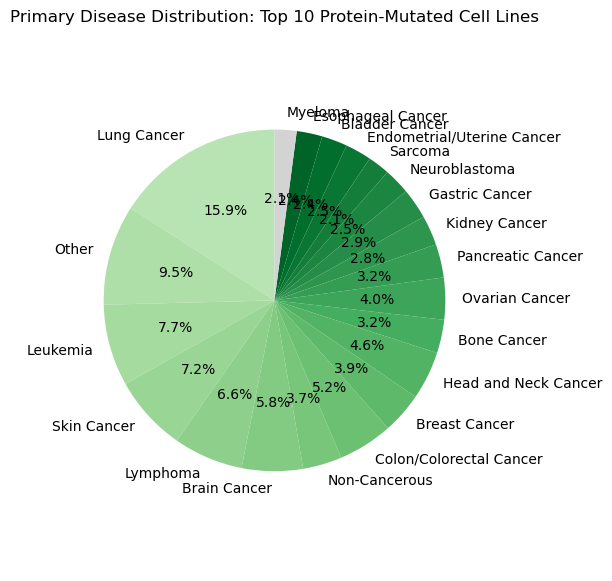

In [4]:
# Top by GI*
# Read top protein list and CCLE mutation data
top10 = pd.read_csv("top10_proteins_list.csv")
dep = pd.read_csv("CCLE_mutations.csv")

# Keep mutations in the top 10 proteins, then get matching metadata
dep_top10 = dep.loc[dep["Hugo_Symbol"].isin(top10["protein"].tolist())].copy()
info_top10 = info.loc[info["DepMap_ID"].isin(dep_top10["DepMap_ID"])].copy()
info_top10 = info_top10.drop_duplicates(subset="DepMap_ID")

# Match tissue order to the first pie chart
top10_counts = make_pie_counts(info_top10)
top10_counts = order_like_reference(top10_counts, reference_order)

plot_tissue_pie(
    top10_counts,
    title="Primary Disease Distribution: Top 10 Protein-Mutated Cell Lines",
    color_map=color_map,
)

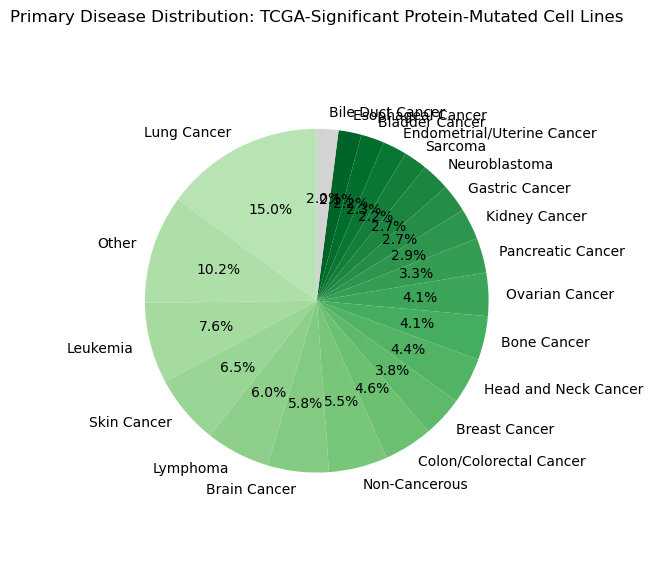

In [5]:
# TCGA
# Read TCGA summary output
tcga_info = pd.read_csv("combined_outputs.csv")

# Proteins with significant TCGA associations
tcga_info["sig"] = np.where(tcga_info["min_pval"] < 0.05, "yes", "no")
sig_proteins = tcga_info.loc[tcga_info["sig"] == "yes", "gene"]

# CCLE cell lines with mutations in significant TCGA proteins
dep_tcga = dep.loc[dep["Hugo_Symbol"].isin(sig_proteins)].copy()
cclelist = dep_tcga["DepMap_ID"].dropna().unique()
info_tcga = info.loc[info["DepMap_ID"].isin(cclelist)].drop_duplicates(subset="DepMap_ID")

# Match tissue order to the first pie chart
tcga_counts = make_pie_counts(info_tcga)
tcga_counts = order_like_reference(tcga_counts, reference_order)

plot_tissue_pie(
    tcga_counts,
    title="Primary Disease Distribution: TCGA-Significant Protein-Mutated Cell Lines",
    color_map=color_map,
)

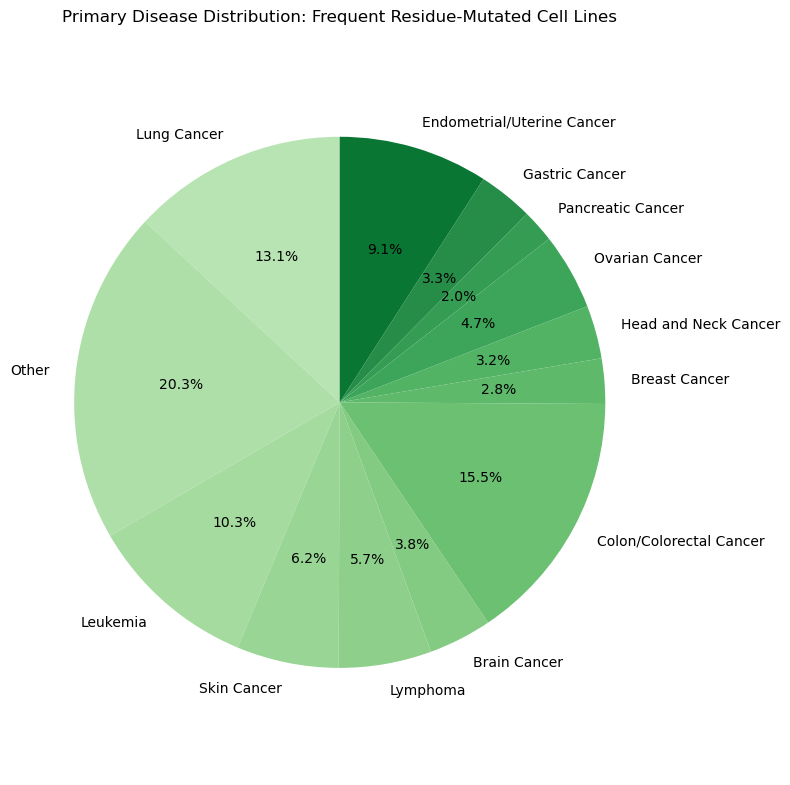

In [6]:
#ClinVar
# Read ClinVar frequency table
clinvar_freq = pd.read_csv("clinvar_frequency_df.csv")

# Frequent protein-residue pairs only
freq_residues = (
    clinvar_freq.loc[clinvar_freq["freq"] == "freq", ["protein", "residue"]]
    .drop_duplicates()
    .copy()
)

# Extract numeric residue from CCLE protein-change annotations
dep_with_residue = dep.copy()
dep_with_residue["residue"] = (
    dep_with_residue["Protein_Change"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

# Match CCLE mutations to frequent residues
merged = dep_with_residue.merge(
    freq_residues,
    left_on=["Hugo_Symbol", "residue"],
    right_on=["protein", "residue"],
    how="inner",
)

# Add primary disease metadata
merged = merged.merge(
    info[["DepMap_ID", "primary_disease"]].drop_duplicates(subset="DepMap_ID"),
    on="DepMap_ID",
    how="left",
)

# Match tissue order to the first pie chart
freq_counts = make_pie_counts(merged)
freq_counts = order_like_reference(freq_counts, reference_order)

plot_tissue_pie(
    freq_counts,
    title="Primary Disease Distribution: Frequent Residue-Mutated Cell Lines",
    color_map=color_map,
    figsize=(8, 8),
)

In [7]:
# top 10 compare
# compare first pie to top10 pie
counts1 = all_counts
counts2 = top10_counts

# make sure both have same tissue order
counts2 = counts2.reindex(counts1.index, fill_value=0)

table = pd.DataFrame({
    "All CCLE": counts1,
    "Top 10": counts2
}).T

chi2, p, dof, expected = chi2_contingency(table)

print("p-value =", p)

p-value = 0.4468961245968378


In [8]:
# tcga compare
# compare first pie to tcga pie
counts1 = all_counts
counts2 = tcga_counts

# make sure both have same tissue order
counts2 = counts2.reindex(counts1.index, fill_value=0)

table = pd.DataFrame({
    "All CCLE": counts1,
    "Top 10": counts2
}).T

chi2, p, dof, expected = chi2_contingency(table)

print("p-value =", p)

p-value = 0.9999074878436396


In [9]:
# clinvar compare
# compare first pie to clinvar pie
counts1 = all_counts.copy()
counts2 = freq_counts.copy()

# only shared tissues
common = counts1.index.intersection(counts2.index)
counts1 = counts1.loc[common]
counts2 = counts2.loc[common]

prop1 = counts1 / counts1.sum()
prop2 = counts2 / counts2.sum()

table = pd.DataFrame({
    "All CCLE": prop1,
    "Freq": prop2
}).T

chi2, p, dof, expected = chi2_contingency(table)

print("p-value =", chi2)

p-value = 0.13508602304920744
